# Pure-Walking PDR
Annotation-free rectangular walk, NU building VU Amsterdam.
Uses the `pdr/` package throughout — see `README_pure_walking_pdr.md` for the development history.


## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid']  = True
plt.rcParams['grid.alpha'] = 0.3

from pdr import (
    load_recording, fix_watch_clock, align_phone_watch,
    detect_steps,
    heading_from_quaternion, select_forward_axis, world_yaw_rate,
    HeadingEKF, integrate_gyro_heading, magnetometer_heading,
    compute_trajectory,
    viz,
)

print('pdr package loaded.')


pdr package loaded.


In [2]:
DIR     = Path('../data/NU/Walking')

FS                = 60.0   # Hz — resample target
WEINBERG_K        = 0.41   # tune against a measured corridor
MIN_PEAK_HEIGHT   = 1.2    # m/s²
MIN_PEAK_DIST_S   = 0.30   # seconds
HEADING_LOWPASS   = 0.5    # Hz — removes step oscillations from heading


## 2. Load & align

`load_recording` reads all CSVs. `fix_watch_clock` corrects the ~17.6-day
epoch offset between the watch and phone before `align_phone_watch` resamples
both devices onto the same 60 Hz grid.
See `preprocess.py` → `fix_watch_clock` for details.


In [3]:
rec = load_recording(DIR)

phone_t0_ns = int(rec.phone.accel_total['time'].iloc[0])
rec.watch   = fix_watch_clock(rec.watch, phone_t0_ns)

phone, watch = align_phone_watch(rec.phone, rec.watch, fs=FS)
t_grid = phone.accel_total['seconds_elapsed'].to_numpy()
print(f'Aligned: {t_grid[-1]:.1f} s  |  {len(t_grid)} samples @ {FS} Hz')


Loaded Walking: phone=10 sensors, watch=7 sensors, annotations=0, duration=110.7s
Aligned: 109.4 s  |  6549 samples @ 60.0 Hz


## 3. Step detection

Watch arm-swing gives cleaner peaks than pocket bounce — used as the primary
source. Phone steps shown alongside for comparison.


Watch : 167 steps  total 120.8 m  mean step 0.723 m
Phone : 175 steps  total 173.1 m  mean step 0.989 m


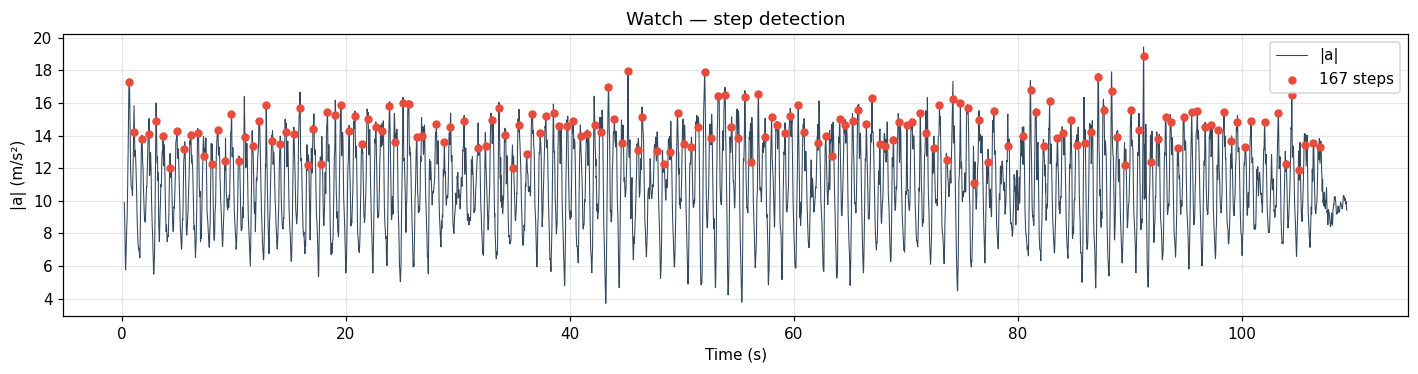

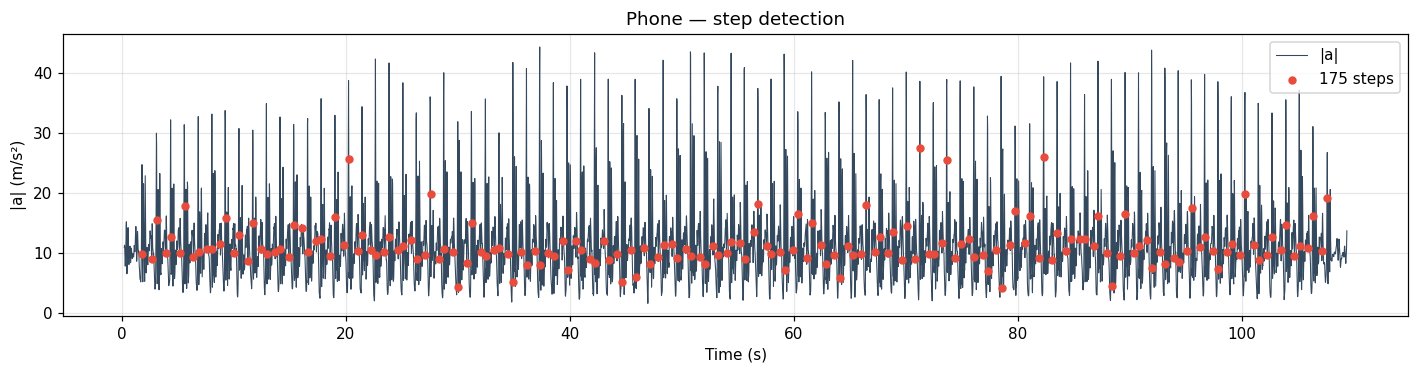

In [4]:
# Watch steps (primary)
w_xyz = watch.accel_total[['x','y','z']].to_numpy()
watch_steps = detect_steps(w_xyz, FS, seconds_elapsed=t_grid,
                            min_peak_height=MIN_PEAK_HEIGHT,
                            min_peak_distance_s=MIN_PEAK_DIST_S,
                            weinberg_k=WEINBERG_K, use_total_accel=True)
print(f'Watch : {len(watch_steps):3d} steps  '
      f'total {sum(s.length for s in watch_steps):.1f} m  '
      f'mean step {np.mean([s.length for s in watch_steps]):.3f} m')

# Phone steps (comparison)
p_xyz = phone.accel_total[['x','y','z']].to_numpy()
phone_steps = detect_steps(p_xyz, FS, seconds_elapsed=t_grid,
                            min_peak_height=MIN_PEAK_HEIGHT,
                            min_peak_distance_s=MIN_PEAK_DIST_S,
                            weinberg_k=WEINBERG_K, use_total_accel=True)
print(f'Phone : {len(phone_steps):3d} steps  '
      f'total {sum(s.length for s in phone_steps):.1f} m  '
      f'mean step {np.mean([s.length for s in phone_steps]):.3f} m')

viz.plot_step_detection(t_grid, w_xyz, watch_steps,
                        title='Watch — step detection', annotations={})
viz.plot_step_detection(t_grid, p_xyz, phone_steps,
                        title='Phone — step detection', annotations={})
plt.show()


## 4. Heading

Three sources compared:

| Source | Method | Notes |
|---|---|---|
| **Quaternion** | rotate phone forward axis to world frame via R | best for arbitrary phone orientation |
| **EKF** | world-frame yaw rate + magnetometer correction | gyro corrected by compass |
| **Gyro only** | world-frame yaw rate integrated | unbounded drift, shown as baseline |

All three now use **world-frame orientation** — the gyro vector is rotated into
the world frame before use, so results are independent of how the phone sits
in the pocket. Previously `gyro_z` was used raw (phone frame), which gave the
wrong sign and magnitude for a pocketed phone.


Forward axis: +X  total turn: -525.3°  (expect ~±360° for a closed loop)
EKF heading  total turn: +99.6°
Gyro-only    total turn: -380.8°


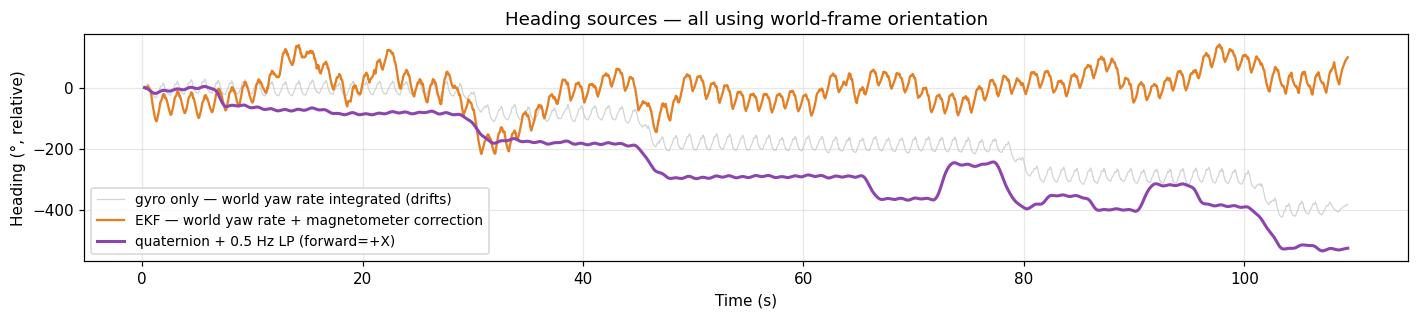

In [5]:
# ── Quaternion heading (primary) ─────────────────────────────────────────────
fwd_name, fwd_axis = select_forward_axis(rec.phone.orientation, t_grid,
                                          fs=FS, lowpass_hz=HEADING_LOWPASS)
h_quat = heading_from_quaternion(rec.phone.orientation, t_grid,
                                  forward_axis=fwd_axis,
                                  lowpass_hz=HEADING_LOWPASS, fs=FS)
print(f'Forward axis: {fwd_name}  '
      f'total turn: {np.degrees(h_quat[-1]):+.1f}°  '
      f'(expect ~±360° for a closed loop)')

# ── World-frame yaw rate (needed for EKF and gyro-only) ──────────────────────
# Raw gyro_z is the rotation around the PHONE z-axis, which is NOT world-vertical
# for a pocketed phone. Rotating the full gyro vector to world frame and taking
# the vertical component gives the true world yaw rate regardless of orientation.
gyro_xyz = phone.gyro[['x','y','z']].to_numpy()
yaw_rate_world = world_yaw_rate(gyro_xyz, rec.phone.orientation, t_grid)

# ── EKF heading (world yaw rate + magnetometer) ───────────────────────────────
m    = phone.magnet[['x','y','z']].to_numpy()
g    = phone.gravity[['x','y','z']].to_numpy()
comp = magnetometer_heading(m, gravity_xyz=g)
ekf  = HeadingEKF(Q=1e-4, R=0.25)
h_ekf = ekf.run(yaw_rate_world, comp, fs=FS)   # world yaw rate, not raw gyro_z
h_ekf = np.unwrap(h_ekf); h_ekf -= h_ekf[0]
print(f'EKF heading  total turn: {np.degrees(h_ekf[-1]):+.1f}°')

# ── Gyro-only heading (world yaw rate integrated) ────────────────────────────
h_gyro = integrate_gyro_heading(yaw_rate_world, fs=FS, initial_heading=0.0)
h_gyro = np.unwrap(h_gyro); h_gyro -= h_gyro[0]
print(f'Gyro-only    total turn: {np.degrees(h_gyro[-1]):+.1f}°')

# ── Plot all three ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(t_grid, np.degrees(h_gyro), color='#bdc3c7', linewidth=0.8,
        alpha=0.7, label='gyro only — world yaw rate integrated (drifts)')
ax.plot(t_grid, np.degrees(h_ekf),  color='#e67e22', linewidth=1.5,
        label='EKF — world yaw rate + magnetometer correction')
ax.plot(t_grid, np.degrees(h_quat), color='#8e44ad', linewidth=2,
        label=f'quaternion + {HEADING_LOWPASS} Hz LP (forward={fwd_name})')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Heading (°, relative)')
ax.set_title('Heading sources — all using world-frame orientation')
ax.legend(fontsize=9)
fig.tight_layout(); plt.show()


## 5. Trajectories

All combinations through `compute_trajectory` from `pdr.py`.
Closure error (end-to-start distance) is the primary accuracy metric —
independent of scale and rotation.


watch steps + quat heading                dist  120.8 m  closure  28.5 m
phone steps + quat heading                dist  173.1 m  closure  36.5 m
watch steps + EKF heading                 dist  120.8 m  closure  75.6 m
phone steps + EKF heading                 dist  173.1 m  closure 105.2 m
phone steps + gyro only                   dist  173.1 m  closure  12.6 m


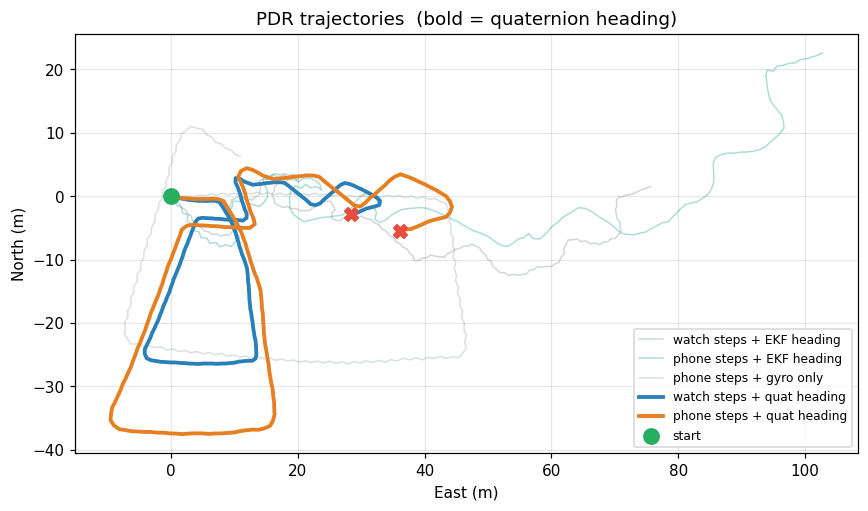

In [6]:
results = {}

for h_label, h_arr in [('quat', h_quat), ('EKF', h_ekf)]:
    for s_label, steps in [('watch', watch_steps), ('phone', phone_steps)]:
        key = f'{s_label} steps + {h_label} heading'
        results[key] = compute_trajectory(steps, h_arr, t_grid)

# Gyro-only as bottom baseline
results['phone steps + gyro only'] = compute_trajectory(phone_steps, h_gyro, t_grid)

for label, res in results.items():
    closure = np.linalg.norm(res.xy[-1])
    print(f'{label:40s}  dist {res.total_distance:6.1f} m  '
          f'closure {closure:5.1f} m')

# Plot — show quat variants prominently, others faint
quat_results  = {k: v for k, v in results.items() if 'quat'  in k}
other_results = {k: v for k, v in results.items() if 'quat' not in k}

fig, ax = plt.subplots(figsize=(8, 8))
palette = ['#2980b9','#e67e22','#7f8c8d','#16a085','#95a5a6']
for (label, res), col in zip(other_results.items(), palette[2:]):
    ax.plot(res.xy[:,0], res.xy[:,1], color=col, linewidth=1,
            alpha=0.35, label=label)
for (label, res), col in zip(quat_results.items(), palette):
    ax.plot(res.xy[:,0], res.xy[:,1], color=col, linewidth=2.5, label=label)
ax.scatter(0, 0, color='#27ae60', s=100, zorder=6, label='start')
for res in quat_results.values():
    ax.scatter(res.xy[-1,0], res.xy[-1,1], color='#e74c3c',
               s=80, marker='X', zorder=6)
ax.set_aspect('equal'); ax.set_xlabel('East (m)'); ax.set_ylabel('North (m)')
ax.set_title('PDR trajectories  (bold = quaternion heading)')
ax.legend(fontsize=8); fig.tight_layout(); plt.show()


## 6. GPS comparison

Same East/North frame, same origin. GPS dots sized by `horizontalAccuracy`.


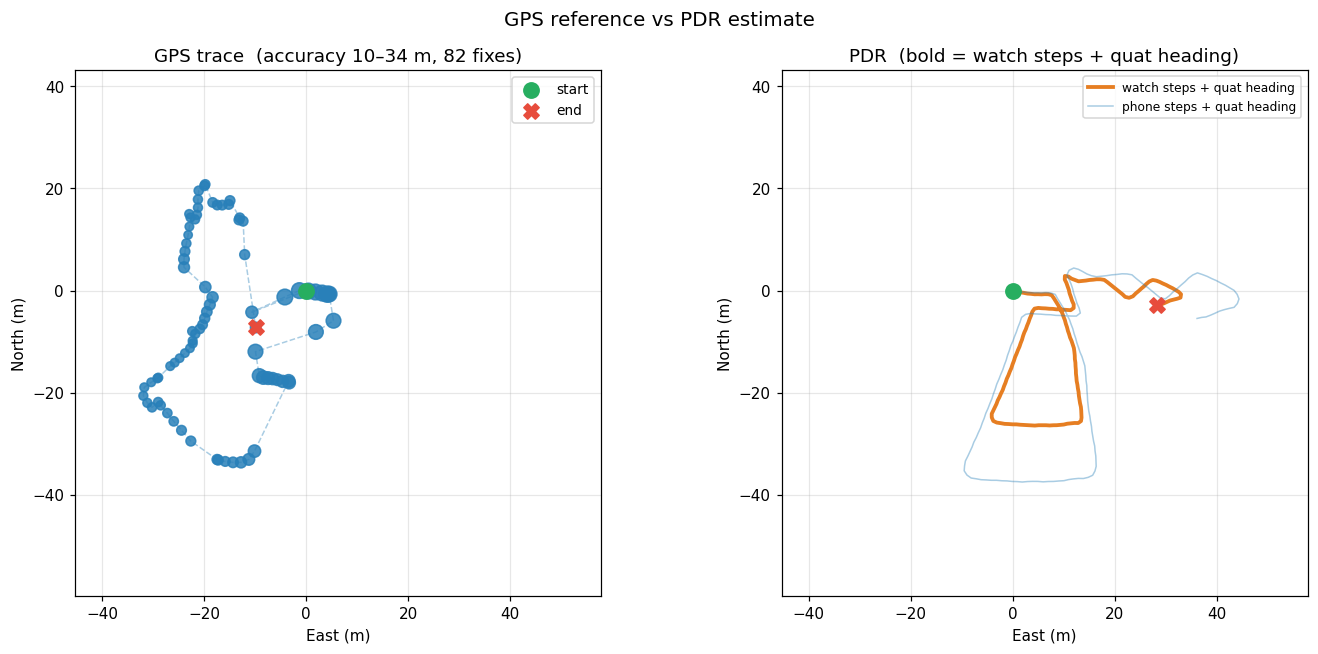

In [7]:
best_key = 'watch steps + quat heading'
viz.plot_gps_vs_pdr(
    {k: v for k, v in results.items() if 'quat' in k},
    rec.phone.location,
    best_key=best_key,
)
plt.show()
